In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
import catboost, lightgbm, xgboost
import pycaret.regression

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform, randint

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

In [2]:
def print_metrics(*metrics, y_true, y_pred):
    metrics_names = {
        r2_score: 'R^2',
        mean_squared_error: 'MSE',
        root_mean_squared_error: 'RMSE',
        mean_absolute_error: 'MAE',
        mean_absolute_percentage_error: 'MAPE' 
    }

    for metric in metrics:
        score = metric(y_true, y_pred)
        if metric == mean_absolute_percentage_error:
            score *= 100 
            print(f"{metrics_names[metric]}: {score} %")
        else:
            print(f"{metrics_names[metric]}: {score}")

# Загрузка и подготовка данных

In [3]:
data = pd.read_csv('/Users/macbook/Desktop/ВУЗ/Машинное обучение и большие данные/lab_1/mumbai_houses.csv')

y = data['price']
X = data.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Решение задачи регрессии

### DecisionTreeRegressor

In [5]:
model = DecisionTreeRegressor()
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)

In [6]:
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 1.0
MSE: 0.0
MAE: 0.0
RMSE: 0.0
MAPE: 0.0 %

Test
R^2: 0.9963160380332343
MSE: 419879797979.798
MAE: 333838.38383838383
RMSE: 647981.325332604
MAPE: 1.8307037532015003 %



### BaggingRegressor

In [7]:
algorithms = [DecisionTreeRegressor(), LinearRegression(), Lasso(), Ridge(), ElasticNet()]

In [8]:
for algorithm in algorithms:    
    print(str(algorithm)[:-2])
    bagging_model = BaggingRegressor(estimator=algorithm)
    bagging_model.fit(X_train_scaled, y_train)

    y_pred_test = bagging_model.predict(X_test_scaled)
    y_pred_train = bagging_model.predict(X_train_scaled)
    print('Train')
    print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
    print()
    print('Test')
    print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
    print()
    print('-' * 30)


DecisionTreeRegressor
Train
R^2: 0.9996520546351358
MSE: 39582300505.05051
MAE: 107785.81267217631
RMSE: 198953.0107966464
MAPE: 0.6163268895097233 %

Test
R^2: 0.9987192194101672
MSE: 145977048668.5032
MAE: 217168.04407713498
RMSE: 382069.4291205503
MAPE: 1.199463640101058 %

------------------------------
LinearRegression
Train
R^2: 0.9532024515274733
MSE: 5323693928966.347
MAE: 1484523.6014543697
RMSE: 2307313.140639204
MAPE: 12.20388349045079 %

Test
R^2: 0.9585272946605873
MSE: 4726854212036.377
MAE: 1420494.080092991
RMSE: 2174132.9793819827
MAPE: 11.16763790112084 %

------------------------------
Lasso
Train
R^2: 0.9532036264658917
MSE: 5323560267850.979
MAE: 1488818.5356962683
RMSE: 2307284.1757900086
MAPE: 12.440046252310994 %

Test
R^2: 0.9585508903305568
MSE: 4724164894060.402
MAE: 1428239.4918850635
RMSE: 2173514.410824185
MAPE: 11.403216376346013 %

------------------------------
Ridge
Train
R^2: 0.9532145836693353
MSE: 5322313775259.908
MAE: 1484823.5649027315
RMSE: 2307

### RandomForestRegressor

In [9]:
bagging_model = RandomForestRegressor()
bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()


Train
R^2: 0.9998670892819437
MSE: 15119936960.514229
MAE: 65692.60789715336
RMSE: 122963.15285691981
MAPE: 0.3810472332844633 %

Test
R^2: 0.9990733323401341
MSE: 105617005096.41873
MAE: 166905.32598714417
RMSE: 324987.69991557946
MAPE: 0.9016695561754566 %



### GradientBoostingRegressor

In [10]:
bagging_model = GradientBoostingRegressor()
bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()


Train
R^2: 0.9981874925905141
MSE: 206191029381.62036
MAE: 343892.1398779463
RMSE: 454082.6239591429
MAPE: 2.212750207099607 %

Test
R^2: 0.9975714302434832
MSE: 276796391478.8648
MAE: 389048.5253186228
RMSE: 526114.4281226897
MAPE: 2.3433433521975697 %



### StackingRegressor

In [11]:
bagging_model = StackingRegressor(estimators=[
        ('dt', DecisionTreeRegressor()),
        ('lasso', Lasso()),
        ('ridge', Ridge()),
        ('enet', ElasticNet())
    ], final_estimator=LinearRegression())
bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.9995504399289381
MSE: 51141999936.65566
MAE: 149358.76216074062
RMSE: 226145.97041878873
MAPE: 1.3402157326530832 %

Test
R^2: 0.9962191394466529
MSE: 430923820509.17456
MAE: 371700.43347064074
RMSE: 656447.8810303028
MAPE: 2.265254037761015 %



### CatBoostRegressor

In [12]:
model = catboost.CatBoostRegressor(verbose=200)
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Learning rate set to 0.05166
0:	learn: 10182621.6393950	total: 56ms	remaining: 56s
200:	learn: 309806.0238148	total: 318ms	remaining: 1.26s
400:	learn: 202040.1331005	total: 485ms	remaining: 725ms
600:	learn: 159908.9695466	total: 653ms	remaining: 433ms
800:	learn: 135914.3051221	total: 822ms	remaining: 204ms
999:	learn: 119851.3702496	total: 995ms	remaining: 0us
Train
R^2: 0.9998737312064027
MSE: 14364350950.709843
MAE: 90746.22253408826
RMSE: 119851.3702496131
MAPE: 0.6060922603565355 %

Test
R^2: 0.9996999846051771
MSE: 34194273585.206223
MAE: 121340.17729304073
RMSE: 184916.93698849282
MAPE: 0.7530166263262689 %



### LGBMRegressor

In [13]:
model = lightgbm.LGBMRegressor(verbose=-1)
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.99954195663856
MSE: 52107059922.86314
MAE: 165828.8017822752
RMSE: 228269.70872821286
MAPE: 1.089215118543623 %

Test
R^2: 0.9990204192993574
MSE: 111647772262.92392
MAE: 227078.43681736293
RMSE: 334137.35538386594
MAPE: 1.3474440983868226 %



### XGBRegressor

In [14]:
model = xgboost.XGBRegressor()
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.9998495170580304
MSE: 17118954960.789755
MAE: 95972.54261363637
RMSE: 130839.42433681736
MAPE: 0.6149694275401766 %

Test
R^2: 0.9987274296374528
MSE: 145041287494.7558
MAE: 250153.58562901744
RMSE: 380842.8645711454
MAPE: 1.4070531422483121 %



# Подбор гиперпараметров

### DecisionTreeRegressor

In [15]:
params = {
    'max_depth': randint(2, 20),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(1, 40),
    'max_features': ['sqrt', 'log2', None],
    'max_leaf_nodes': randint(2, 20),
    'min_impurity_decrease': uniform(0.01, 0.1),
    'ccp_alpha': uniform(0.01, 0.05)
}

Лучшие параметры: {'ccp_alpha': 0.03125330754476523, 'max_depth': 12, 'max_features': None, 'max_leaf_nodes': 18, 'min_impurity_decrease': 0.09283634693371633, 'min_samples_leaf': 27, 'min_samples_split': 22}
Лучший score: -8692644692038.791
Train
R^2: 0.9305791458482415
MSE: 7897323510618.082
MAE: 2185643.3929633815
RMSE: 2810217.6980828517
MAPE: 14.452399012802159 %

Test
R^2: 0.9266013671966287
MSE: 8365613812384.1
MAE: 2280633.5546802166
RMSE: 2892337.084847494
MAPE: 14.763374479226258 %



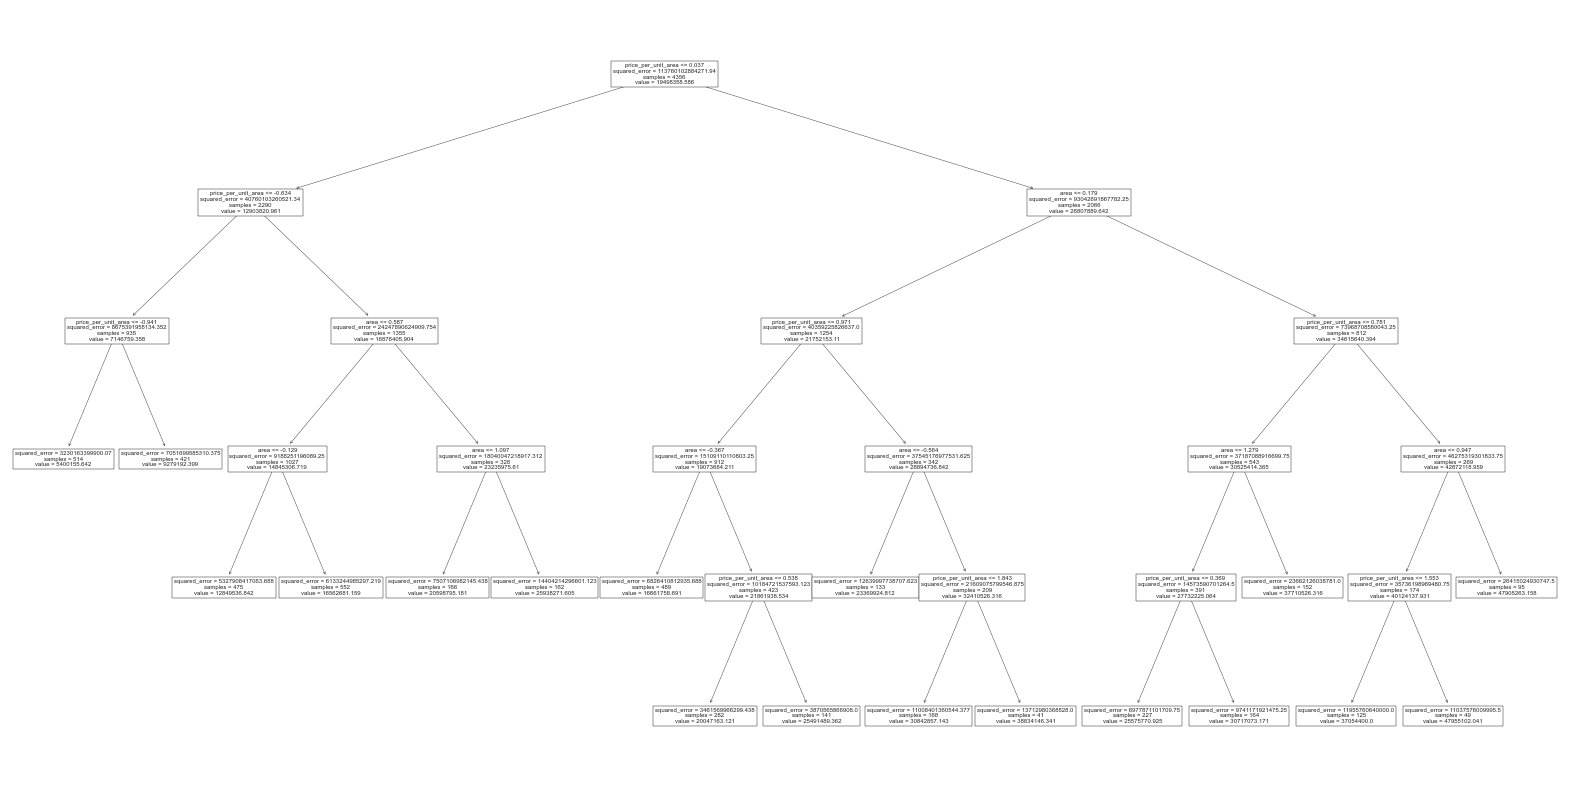

In [16]:
model = DecisionTreeRegressor(criterion='squared_error', splitter='best', random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=50, cv=5, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

plt.figure(figsize=(20, 10))
plot_tree(rs.best_estimator_, feature_names=X_train.columns)
plt.show()

### BaggingRegressor

In [17]:
params = {
    'n_estimators': randint(2, 100),
    'max_samples': uniform(0.1, 0.9),
    'max_features': uniform(0.1, 0.9),
}

In [18]:
model = BaggingRegressor(estimator=DecisionTreeRegressor(criterion='squared_error', splitter='best', random_state=42), bootstrap=True, bootstrap_features=True)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=2, n_iter=50, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'max_features': 0.9632218926739008, 'max_samples': 0.5945420352432572, 'n_estimators': 42}
Лучший score: -7194271499484.564
Train
R^2: 0.9814820913004634
MSE: 2106599198860.8467
MAE: 1039254.7953279148
RMSE: 1451412.8285435701
MAPE: 6.680916981954701 %

Test
R^2: 0.9499040961629531
MSE: 5709683805769.954
MAE: 1680133.1589853188
RMSE: 2389494.466570273
MAPE: 10.234886081195642 %



### RandomForestRegressor

In [19]:
params = {
    'n_estimators': randint(2, 100),
    'max_depth': randint(2, 5),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
}

In [20]:
model = RandomForestRegressor(criterion='squared_error', max_features=1/3, max_samples=1.0, bootstrap=True, random_state=42)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=2, n_iter=50, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'max_depth': 4, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'min_samples_split': 36, 'n_estimators': 73}
Лучший score: 15311192649974.06
Train
R^2: 0.8766315158174651
MSE: 14034411453281.855
MAE: 2622211.9872882036
RMSE: 3746252.988424815
MAPE: 19.074699062783594 %

Test
R^2: 0.8681112930123852
MSE: 15032023713967.486
MAE: 2661032.572629045
RMSE: 3877115.3856917243
MAPE: 18.316658811992088 %



### GradientBoostingRegressor

In [21]:
params = {
    'learning_rate': uniform(0.1, 0.5),
    'n_estimators': randint(2, 100),
    'max_depth': randint(1, 3),
    'min_samples_split': randint(2, 40),
    'min_samples_leaf': randint(10, 40),
    'max_leaf_nodes': randint(2, 20),
    'ccp_alpha': uniform(0.0, 0.3)
}

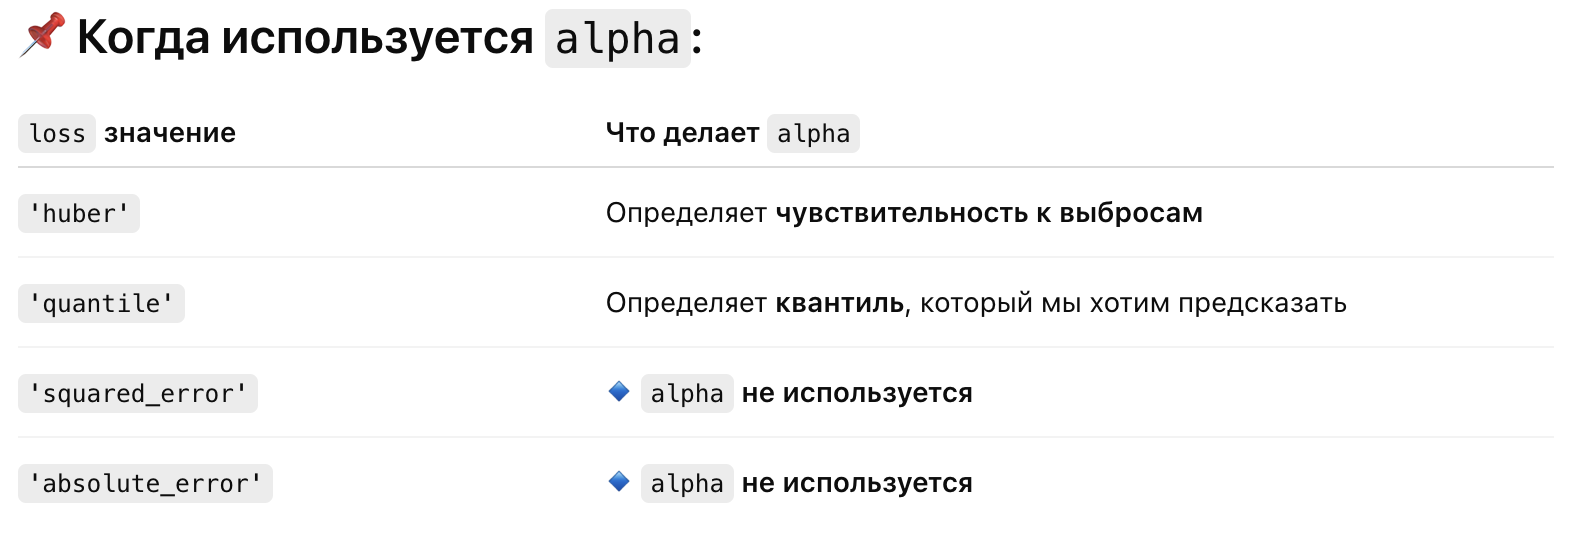

In [22]:
model = GradientBoostingRegressor(loss='squared_error', subsample=1.0, criterion='friedman_mse', random_state=42, max_features=1/3)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=3, n_iter=50, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'ccp_alpha': 0.1531354622690448, 'learning_rate': 0.3524447773316427, 'max_depth': 2, 'max_leaf_nodes': 6, 'min_samples_leaf': 21, 'min_samples_split': 29, 'n_estimators': 94}
Лучший score: 2121711399923.3386
Train
R^2: 0.9834628421341898
MSE: 1881268780228.023
MAE: 988705.9610566022
RMSE: 1371593.5185863278
MAPE: 6.5337525850325315 %

Test
R^2: 0.9799133544264468
MSE: 2289376698674.184
MAE: 1047370.1360596395
RMSE: 1513068.636471652
MAPE: 6.5123198602525845 %



### StackingRegressor

In [23]:
bagging_model = StackingRegressor(estimators=[
        ('dt', DecisionTreeRegressor(max_depth=5, random_state=42)),
        ('lasso', Lasso(alpha=0.9, max_iter=4000, random_state=42)),
        ('ridge', Ridge(alpha=0.9, max_iter=1000, random_state=42)),
        ('enet', ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=1000, random_state=42))
    ], final_estimator=LinearRegression(), cv=5)

bagging_model.fit(X_train_scaled, y_train)

y_pred_test = bagging_model.predict(X_test_scaled)
y_pred_train = bagging_model.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Train
R^2: 0.976491315057987
MSE: 2674350417677.327
MAE: 1198694.070523181
RMSE: 1635344.1282119574
MAPE: 8.8234143304507 %

Test
R^2: 0.9747468453889359
MSE: 2878229892735.6357
MAE: 1232352.1143567658
RMSE: 1696534.6718342174
MAPE: 8.532532971094835 %



### CatBoostRegressor

In [24]:
params = {
    'iterations': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(4, 10),
    'grow_policy': ['SymmetricTree', 'Depthwise', 'Lossguide']
}

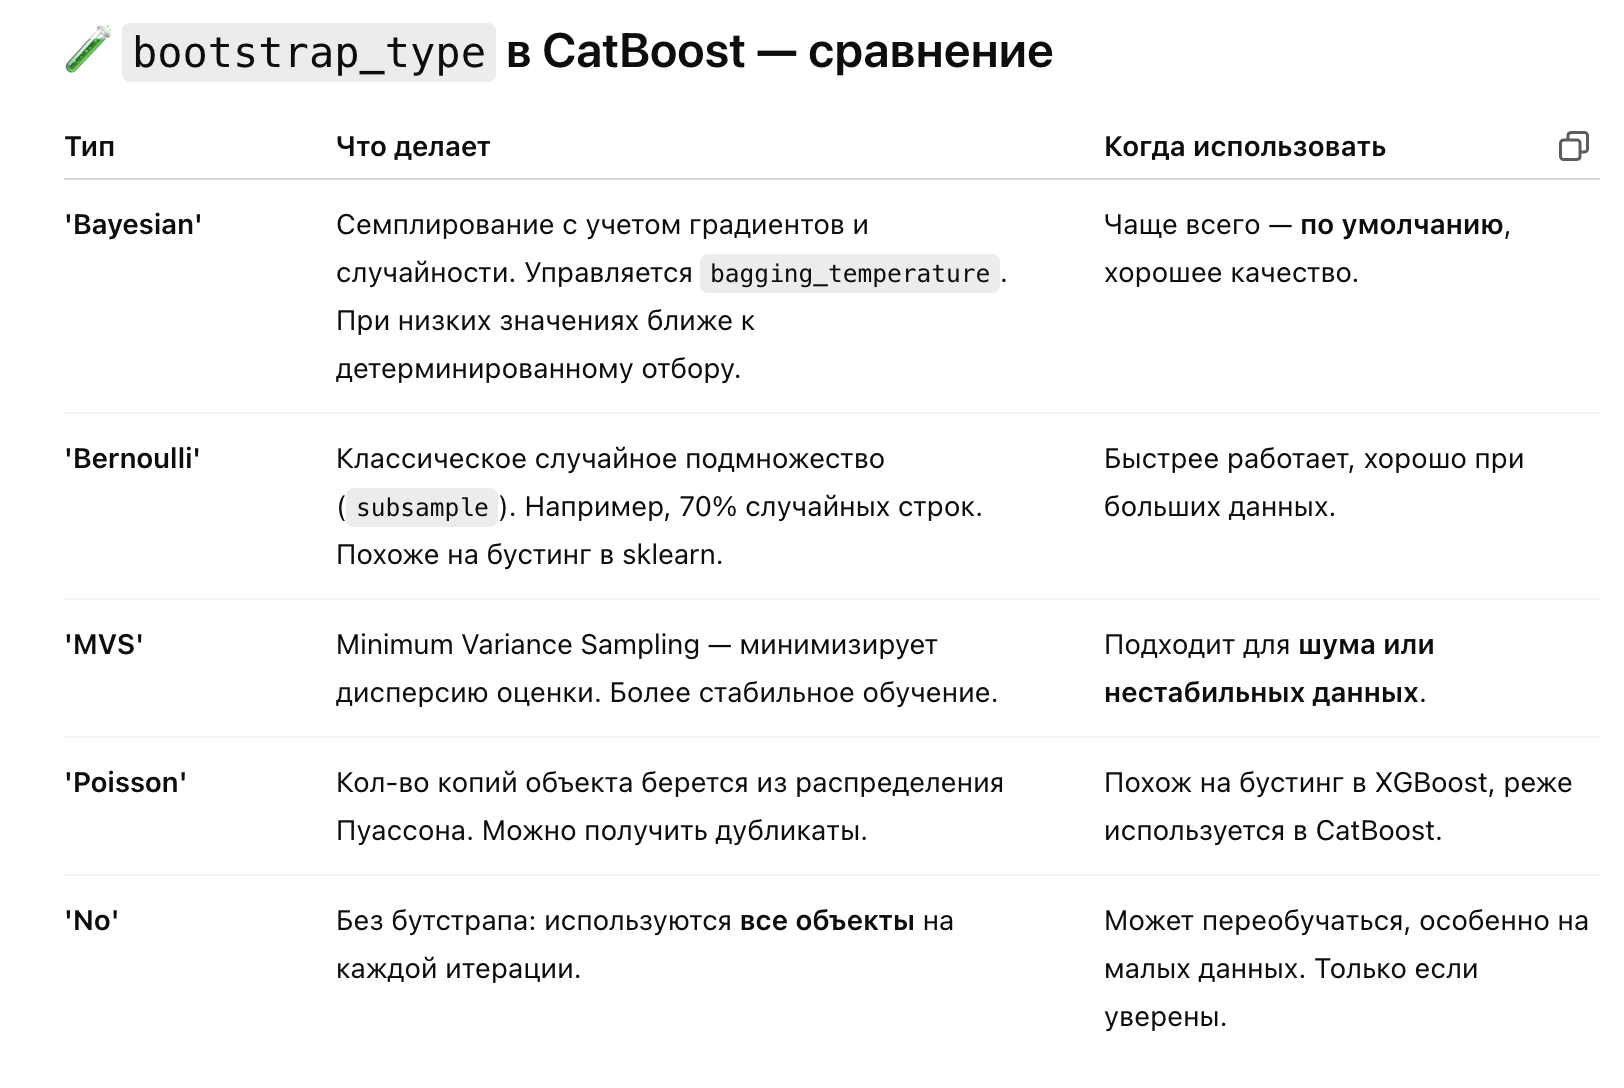

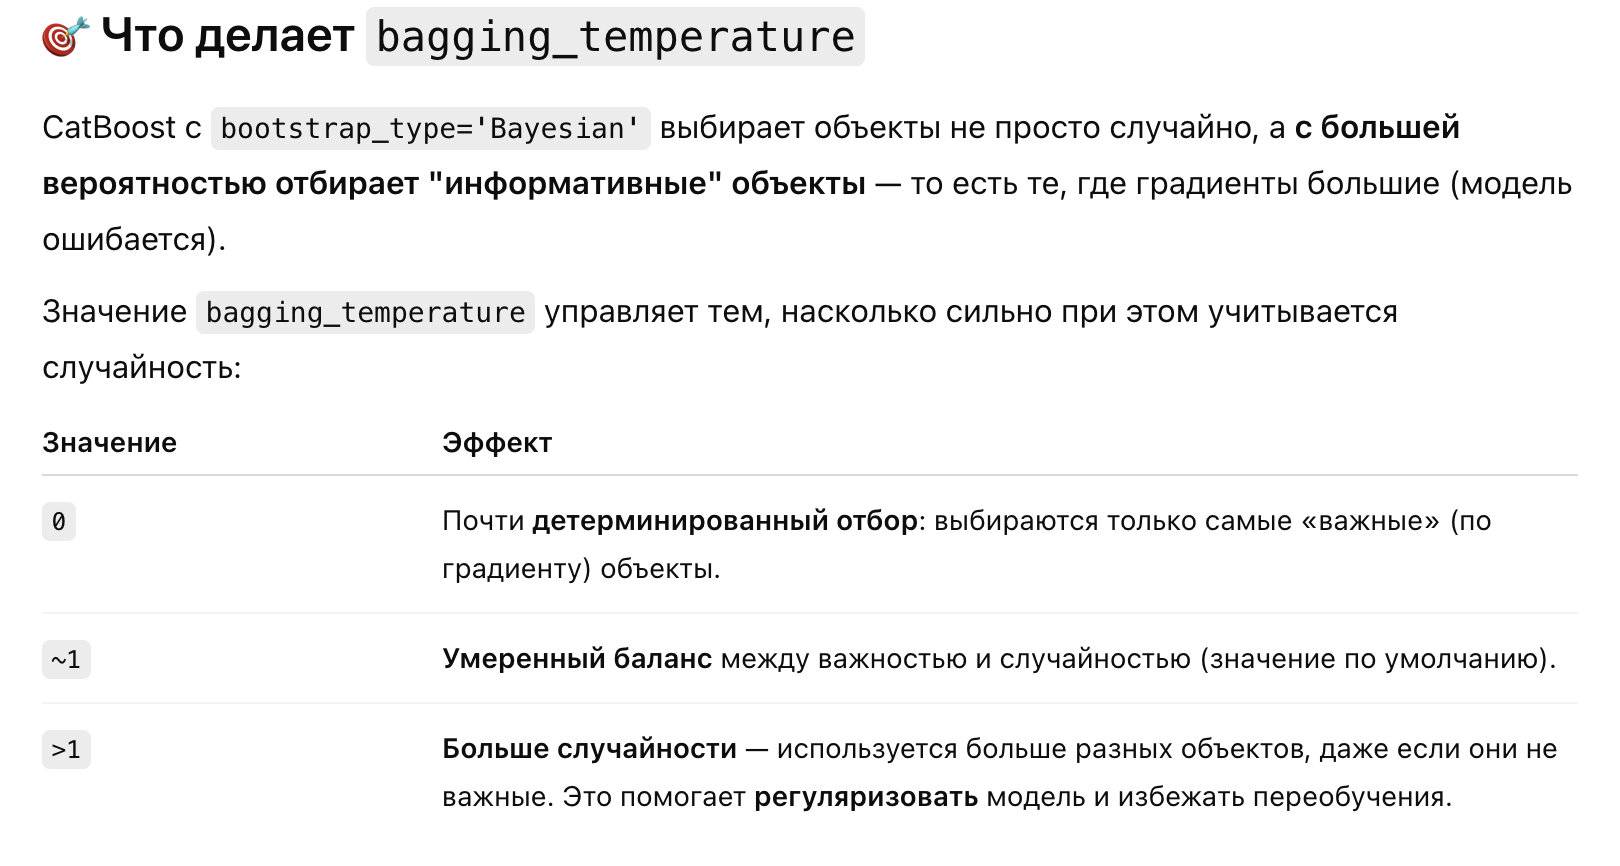

In [25]:
model = catboost.CatBoostRegressor(loss_function='RMSE', bootstrap_type='Bayesian', bagging_temperature=1, random_state=42, verbose=0)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=3, n_iter=20, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'depth': 5, 'grow_policy': 'SymmetricTree', 'iterations': 764, 'learning_rate': 0.141706565216002}
Лучший score: 82189730476.77911
Train
R^2: 0.999837805342373
MSE: 18451280938.922676
MAE: 106028.26480288681
RMSE: 135835.49219155748
MAPE: 0.7279381329824681 %

Test
R^2: 0.9995486201520998
MSE: 51446046690.56216
MAE: 149947.90309063796
RMSE: 226817.20986415946
MAPE: 0.9213715642190374 %



### XGBRegressor

In [26]:
params = {
    'n_estimators': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(4, 10),
    'booster': ['gbtree', 'gblinear', 'dart'],
}

In [27]:
model = xgboost.XGBRegressor(objective='reg:squarederror', verbosity=2)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=2, n_iter=2, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

Лучшие параметры: {'booster': 'gblinear', 'learning_rate': 0.21797780827795774, 'max_depth': 8, 'n_estimators': 191}
Лучший score: 5372416971388.404
Train
R^2: 0.9532263023884889
MSE: 5320980652563.331
MAE: 1486335.4391486777
RMSE: 2306725.0925420937
MAPE: 12.30151488290239 %

Test
R^2: 0.9585344472777418
MSE: 4726038992044.152
MAE: 1424903.2361720903
RMSE: 2173945.4896671516
MAPE: 11.26972501897053 %



### LGBMRegressor

In [28]:
params = {
    'n_estimators': randint(2, 1000),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(4, 10),
    'boosting_type': ['gbdt', 'dart', 'goss', 'rf'],
}

In [29]:
model = lightgbm.LGBMRegressor(objective='mse', verbosity=1)

rs = RandomizedSearchCV(estimator=model, param_distributions=params, cv=2, n_iter=2, scoring='neg_mean_squared_error')
rs.fit(X_train_scaled, y_train)

print("Лучшие параметры:", rs.best_params_)
print("Лучший score:", -rs.best_score_)

y_pred_test = rs.predict(X_test_scaled)
y_pred_train = rs.predict(X_train_scaled)
print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train)
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test)
print()

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000750 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1053
[LightGBM] [Info] Number of data points in the train set: 2178, number of used features: 13
[LightGBM] [Info] Using GOSS
[LightGBM] [Info] Start training from score 19482070.707071
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## PyCaret

In [30]:
from pycaret.regression import setup, compare_models, tune_model, get_config, predict_model, models

In [34]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [33]:
reg = setup(data=data, target='price', session_id=42, normalize=True, normalize_method='robust')

best_model = compare_models()

,Description,Value
0,Session id,42
1,Target,price
2,Target type,Regression
3,Original data shape,"(5445, 16)"
4,Transformed data shape,"(5445, 16)"
5,Transformed train set shape,"(3811, 16)"
6,Transformed test set shape,"(1634, 16)"
7,Numeric features,11
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,142527.4707,55227090917.9667,230144.0542,0.9995,0.0201,0.0094,0.2550
et,Extra Trees Regressor,159295.1423,118837540738.3848,332301.1362,0.9990,0.0233,0.0097,0.0720
rf,Random Forest Regressor,189915.8198,143292531279.8780,369888.3598,0.9988,0.0232,0.0112,0.1160
lightgbm,Light Gradient Boosting Machine,245618.7784,147587938751.4040,380818.9819,0.9987,0.0266,0.0151,0.5010
xgboost,Extreme Gradient Boosting,283342.8078,196010897408.0000,440289.8906,0.9983,0.0275,0.0167,0.0180
gbr,Gradient Boosting Regressor,393938.4739,305344461011.9480,549507.8775,0.9973,0.0355,0.0242,0.0480
dt,Decision Tree Regressor,404518.8056,570227895040.6069,753637.4313,0.9950,0.0431,0.0233,0.0070
ridge,Ridge Regression,1497003.1875,5437385133260.7998,2329017.3000,0.9524,0.3465,0.1242,0.0060
lar,Least Angle Regression,1497869.1750,5440871596032.0000,2329721.9750,0.9523,0.3475,0.1244,0.0060
lr,Linear Regression,1497714.4000,5438982271795.2002,2329370.9500,0.9523,0.3474,0.1244,0.2550


In [35]:
tuned_model = tune_model(best_model)

X_train = get_config('X_train')
y_train = get_config('y_train')
X_test = get_config('X_test')
y_test = get_config('y_test')

y_pred_test = predict_model(tuned_model, data=X_test)
y_pred_train = predict_model(tuned_model, data=X_train)

print('Train')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_train, y_pred=y_pred_train['prediction_label'])
print()
print('Test')
print_metrics(r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, y_true=y_test, y_pred=y_pred_test['prediction_label'])
print()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,508355.2848,470775175674.0279,686130.5821,0.9960,0.0674,0.0361
1,513235.0271,472208492353.4747,687174.2809,0.9957,0.0666,0.0379
2,529449.5151,475161762463.7557,689319.7824,0.9957,0.0507,0.0345
3,506352.1910,423968092414.6099,651128.3225,0.9965,0.0463,0.0333
4,487182.6185,435727645096.2123,660096.6937,0.9961,0.0474,0.0316
5,505928.5190,415672600148.4940,644726.7639,0.9963,0.0590,0.0352
6,529656.1104,472753645584.9250,687570.8295,0.9955,0.0486,0.0342
7,479892.8654,426066640111.2628,652737.8035,0.9964,0.0580,0.0357
8,535817.2525,520396890529.8343,721385.3967,0.9957,0.0515,0.0347


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


Train
R^2: 0.9998681577128131
MSE: 15054114357.81184
MAE: 94585.28083889777
RMSE: 122695.20918850842
MAPE: 0.6338823080425106 %

Test
R^2: 0.9996603628673044
MSE: 38339470995.578445
MAE: 131117.98999209853
RMSE: 195804.67562236212
MAPE: 0.8155213982737558 %



In [36]:
print(tuned_model.get_params())

{'loss_function': 'RMSE', 'border_count': 254, 'verbose': False, 'task_type': 'CPU', 'random_state': 42}
